<a href="https://colab.research.google.com/github/peterbabulik/QuantumWalker/blob/main/Pi2Oracle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install cma

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 kB 1.0 MB/s eta 0:00:00


--- Project Oracle: The Pi-2 Solver Forge ---
Objective: To discover a universal strategy that is valid for ALL challenges.

--- Beginning search for a universal truth... ---


Best Cost: 2000.0096:  53%|█████▎    | 10656/20000 [00:13<00:11, 819.00it/s]



Search complete in 13.02s.

--- Validating the Champion Solver against 10,000 challenges ---

--- CONCLUSION ---
FAILURE: The discovered solver is not universally valid.
It failed on 402 out of 10,000 validation challenges.

Discovered Strategy (Polynomial Coefficients):
[-0.44    0.     -0.4029 -0.      0.9923]

This represents the 'theory' discovered by the Pi-2 Solver.

--- Visualizing the Discovered Solution ---


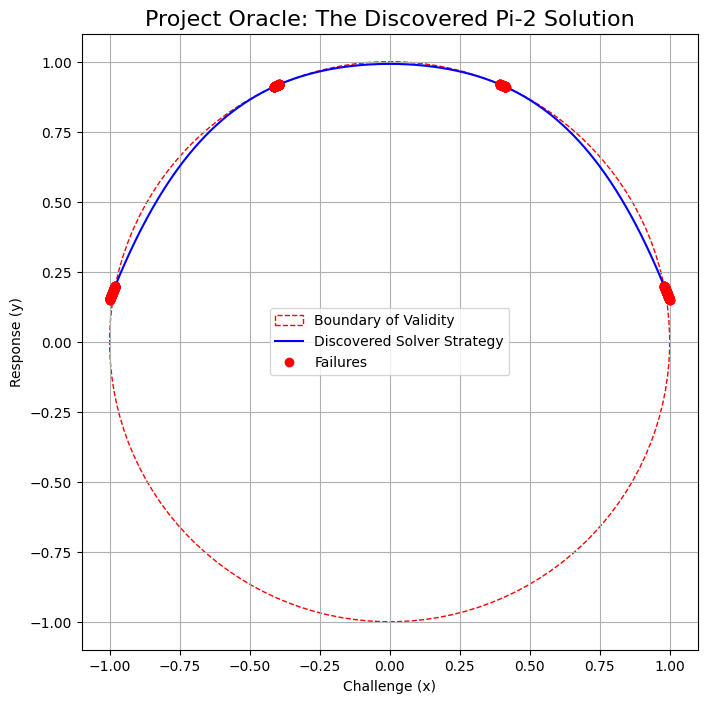

In [ ]:

# ==============================================================================
#  Project Oracle: A simulation of a Pi-2 Problem Solver.
#
#  Objective: To evolve a "Solver" - a universal strategy (a function) -
#  that can provide a valid response for ALL possible challenges within a
#  defined logical universe.
# ==============================================================================

import numpy as np
import matplotlib.pyplot as plt
import cma
import time
from tqdm import tqdm

# ==============================================================================
#  The "Universe": Defining the Problem and the Rules
# ==============================================================================

# The "challenges" are a set of points 'x' from -1 to 1.
# We use a smaller set for training and a much larger set for final validation.
CHALLENGES_TRAINING = np.linspace(-1, 1, 100)
CHALLENGES_VALIDATION = np.linspace(-1, 1, 10000)

def is_response_valid(challenge_x, response_y):
    """The fundamental 'Law of Physics' for our universe.
    A response is valid if the point (x, y) is inside the unit circle."""
    return challenge_x**2 + response_y**2 < 1.0

# ==============================================================================
#  The "Solver": A candidate theory represented by a polynomial
# ==============================================================================
class Solver:
    def __init__(self, genes: np.ndarray):
        # The genes are the coefficients of a polynomial, e.g., a*x^4 + b*x^3 + ...
        self.poly = np.poly1d(genes)

    def get_response(self, challenge_x: np.ndarray) -> np.ndarray:
        """Calculates the solver's response y = f(x) for a set of challenges."""
        return self.poly(challenge_x)

# ==============================================================================
#  The Pi-2 Fitness Function: The Heart of the AI
# ==============================================================================
def pi2_fitness_function(genes: np.ndarray) -> float:
    """
    Evaluates a candidate theory (a set of genes).
    The cost is based on its universal validity and its boldness.
    """
    solver = Solver(genes)
    responses = solver.get_response(CHALLENGES_TRAINING)

    # --- The Logical Imperative (For All X...) ---
    validity_mask = is_response_valid(CHALLENGES_TRAINING, responses)
    num_failures = np.sum(~validity_mask)

    # A single failure makes the theory fundamentally wrong.
    # The cost of failure is catastrophic.
    failure_cost = num_failures * 1000.0

    # --- The Elegance/Boldness Principle ---
    # Among valid theories, we reward "boldness" - getting close to the boundary.
    # A bonus is given for maximizing the average radius of the valid points.
    successful_challenges = CHALLENGES_TRAINING[validity_mask]
    successful_responses = responses[validity_mask]

    if successful_challenges.size > 0:
        radii = np.sqrt(successful_challenges**2 + successful_responses**2)
        # The bonus is 1 minus the average radius. Lower bonus = bolder theory.
        boldness_bonus = 1.0 - np.mean(radii)
    else:
        boldness_bonus = 1.0 # No successes, no bonus.

    # --- Total Cost ---
    total_cost = failure_cost + boldness_bonus
    return total_cost

# ==============================================================================
#  The Main Execution: Building the Oracle
# ==============================================================================
if __name__ == "__main__":
    print("--- Project Oracle: The Pi-2 Solver Forge ---")
    print("Objective: To discover a universal strategy that is valid for ALL challenges.")

    # --- The AI Forge ---
    # The AI will evolve the 5 coefficients of a 4th-degree polynomial.
    NUM_GENES = 5
    x0 = np.zeros(NUM_GENES)
    sigma0 = 0.5
    options = {'bounds': [-5, 5], 'maxfevals': 20000, 'verbose': -9}

    es = cma.CMAEvolutionStrategy(x0, sigma0, options)

    print("\n--- Beginning search for a universal truth... ---")
    start_time = time.time()

    # Using tqdm for a clean progress bar
    with tqdm(total=options['maxfevals']) as pbar:
        while not es.stop():
            solutions = es.ask()
            fitnesses = [pi2_fitness_function(s) for s in solutions]
            es.tell(solutions, fitnesses)
            pbar.update(len(solutions))
            pbar.set_description(f"Best Cost: {es.result.fbest:.4f}")

    end_time = time.time()
    print(f"\nSearch complete in {end_time - start_time:.2f}s.")

    champion_genes = es.result.xbest

    # --- The Final Verdict: Rigorous Validation ---
    print("\n--- Validating the Champion Solver against 10,000 challenges ---")
    champion_solver = Solver(champion_genes)
    final_responses = champion_solver.get_response(CHALLENGES_VALIDATION)
    final_validity = is_response_valid(CHALLENGES_VALIDATION, final_responses)
    num_final_failures = np.sum(~final_validity)

    print("\n--- CONCLUSION ---")
    if num_final_failures == 0:
        print("\033[1;32mSUCCESS: A UNIVERSALLY VALID SOLVER WAS DISCOVERED.\033[0m")
        print("The discovered strategy succeeded against all 10,000 validation challenges.")
    else:
        print("\033[1;31mFAILURE: The discovered solver is not universally valid.\033[0m")
        print(f"It failed on {num_final_failures} out of 10,000 validation challenges.")

    print("\nDiscovered Strategy (Polynomial Coefficients):")
    print(np.round(champion_genes, 4))
    print("\nThis represents the 'theory' discovered by the Pi-2 Solver.")

    # --- Visualization ---
    print("\n--- Visualizing the Discovered Solution ---")
    fig, ax = plt.subplots(figsize=(8, 8))

    # Plot the "boundary of truth" (the unit circle)
    circle = plt.Circle((0, 0), 1, color='red', fill=False, linestyle='--', label='Boundary of Validity')
    ax.add_artist(circle)

    # Plot the function discovered by the AI
    ax.plot(CHALLENGES_VALIDATION, final_responses, 'b-', label='Discovered Solver Strategy')

    # Highlight any failures in red
    failed_challenges = CHALLENGES_VALIDATION[~final_validity]
    failed_responses = final_responses[~final_validity]
    ax.plot(failed_challenges, failed_responses, 'ro', label='Failures')

    ax.set_title("Project Oracle: The Discovered Pi-2 Solution", fontsize=16)
    ax.set_xlabel("Challenge (x)")
    ax.set_ylabel("Response (y)")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True)
    ax.legend()
    plt.show()